# Experiment 02 Underwater Pendula

## Preliminaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
path = 'data/'

uw_m1 = pd.read_csv(path + 'uw_m1_tracked_positions.csv')
uw_m2 = pd.read_csv(path + 'uw_m2_tracked_positions.csv')
uw_m3 = pd.read_csv(path + 'uw_m3_tracked_positions.csv')

m1 = pd.read_csv(path + 'M1T3_positions.csv')
m2 = pd.read_csv(path + 'M2T1_positions.csv')
m3 = pd.read_csv(path + 'M3T1_fixed_positions.csv')

spring_m3 = pd.read_csv(path + 'spring_m3_tracked_positions.csv')

## Defining Functions

In [3]:
def frame_to_sec(df, fps):
    df['time'] = df['frame']/fps
    return df

def theta(df, lim1, lim2):
    lim2 = lim1 + 1
    df = df[(df['time'] > lim1) & (df['time'] <= lim2)]
    theta = np.arctan2(df['dx_from_ref'], df['dy_from_ref'])
    theta = np.unwrap(theta)
    df_out = pd.DataFrame({
        "angle": theta, 
        "time": df['time']
    })
    return df_out

def theta2(df, lim1, lim2):
    df = df[(df['time'] > lim1) & (df['time'] <= lim2)]
    theta = np.arctan2(df['dx_from_ref'], df['dy_from_ref'])
    theta = np.unwrap(theta)
    df_out = pd.DataFrame({
        "angle": theta, 
        "time": df['time']
    })
    return df_out

In [4]:
def plotter(df, title1, title2, yticks1, yticks2, xticks, output_folder, filename):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 5))

    x, y, time = df['x'], df['y'], df['time']

    ax[0].plot(time, x, color='C0')
    ax[0].set_title(title1)
    ax[0].set_ylabel('Position (pixels)')
    ax[0].set_yticks(yticks1)
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(time, y, color='C1')
    ax[1].set_title(title2)
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Position (pixels)')
    ax[1].invert_yaxis()
    ax[1].set_xticks(xticks)
    ax[1].set_xticklabels([0, 1, 2, 3, 4, 5])
    ax[1].set_yticks(yticks2)
    ax[1].grid()

    os.makedirs(output_folder, exist_ok=True)

    save_path = os.path.join(output_folder, f"{filename}.png")
    plt.savefig(save_path, dpi=300)

## Implementing Functions

In [5]:
uw_m1 = frame_to_sec(uw_m1, 60)
uw_m2 = frame_to_sec(uw_m2, 60)
uw_m3 = frame_to_sec(uw_m3, 60)

m1 = frame_to_sec(m1, 60)
m2 = frame_to_sec(m2, 60)
m3 = frame_to_sec(m3, 60)

spring_m3 = frame_to_sec(spring_m3, 60)

## Plots of Position (non-underwater)

C:\Users\David\AppData\Local\Temp\ipykernel_5804\850648379.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


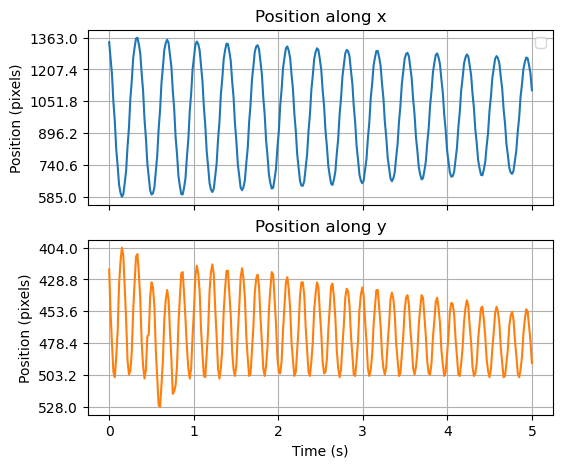

In [6]:
m1 = m1[(m1['time'] > 1.15) & (m1['time'] <= 6.15)]

plotter(m1, 'Position along x', 'Position along y', 
        np.linspace(np.min(m1['x']), np.max(m1['x']), 6),
        np.linspace(np.min(m1['y']), np.max(m1['y']), 6),
        np.linspace(np.min(m1['time']), np.max(m1['time']), 6),
        'plots', 'position vs time m1 in air')

C:\Users\David\AppData\Local\Temp\ipykernel_5804\850648379.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


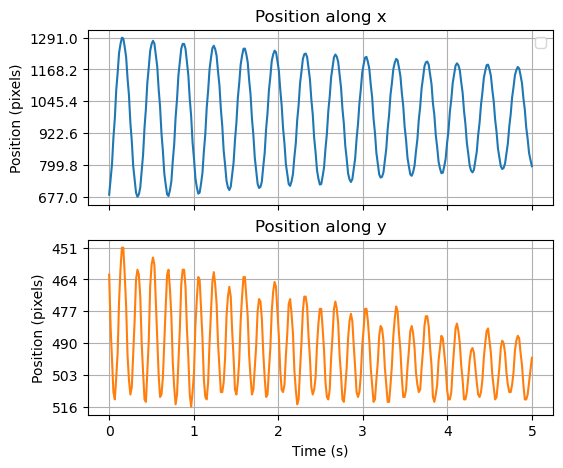

In [7]:
m2 = m2[(m2['time'] > 0.45) & (m2['time'] <= 5.45)]

plotter(m2, 'Position along x', 'Position along y', 
        np.linspace(np.min(m2['x']), np.max(m2['x']), 6),
        np.linspace(np.min(m2['y']), np.max(m2['y']), 6),
        np.linspace(np.min(m2['time']), np.max(m2['time']), 6),
        'plots', 'position vs time m2 in air')

C:\Users\David\AppData\Local\Temp\ipykernel_5804\850648379.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


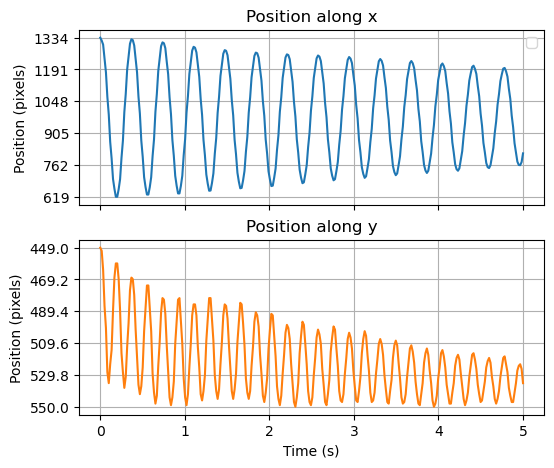

In [8]:
m3 = m3[(m3['time'] > 0) & (m3['time'] <= 5)]

plotter(m3, 'Position along x', 'Position along y', 
        np.linspace(np.min(m3['x']), np.max(m3['x']), 6),
        np.linspace(np.min(m3['y']), np.max(m3['y']), 6),
        np.linspace(np.min(m3['time']), np.max(m3['time']), 6),
        'plots', 'position vs time m3 in air')

## Plots of Position (underwater)

C:\Users\David\AppData\Local\Temp\ipykernel_5804\850648379.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


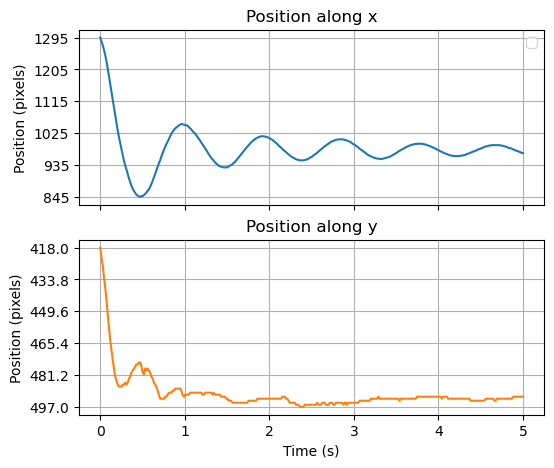

In [9]:
plotter(uw_m1, 'Position along x', 'Position along y', 
        np.linspace(np.min(uw_m1['x']), np.max(uw_m1['x']), 6),
        np.linspace(np.min(uw_m1['y']), np.max(uw_m1['y']), 6), 
        np.linspace(np.min(uw_m1['time']), np.max(uw_m1['time']), 6),
        'plots', 'position vs time m1 in water')

C:\Users\David\AppData\Local\Temp\ipykernel_5804\850648379.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


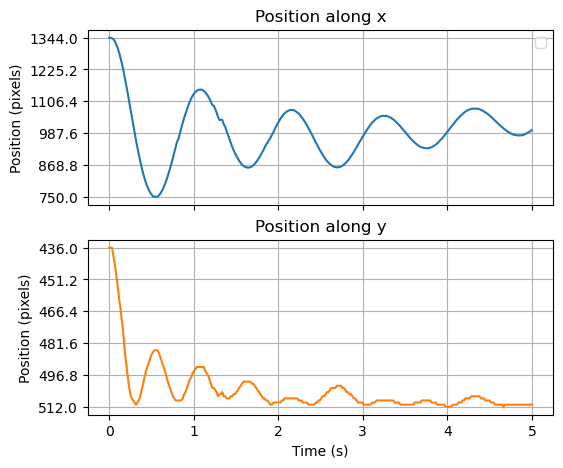

In [10]:
uw_m2 = uw_m2[(uw_m2['time'] > 0.45) & (uw_m2['time'] <= 5.45)]

plotter(uw_m2, 'Position along x', 'Position along y', 
        np.linspace(np.min(uw_m2['x']), np.max(uw_m2['x']), 6),
        np.linspace(np.min(uw_m2['y']), np.max(uw_m2['y']), 6), 
        np.linspace(np.min(uw_m2['time']), np.max(uw_m2['time']), 6),
        'plots', 'position vs time m2 in water')

C:\Users\David\AppData\Local\Temp\ipykernel_5804\850648379.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


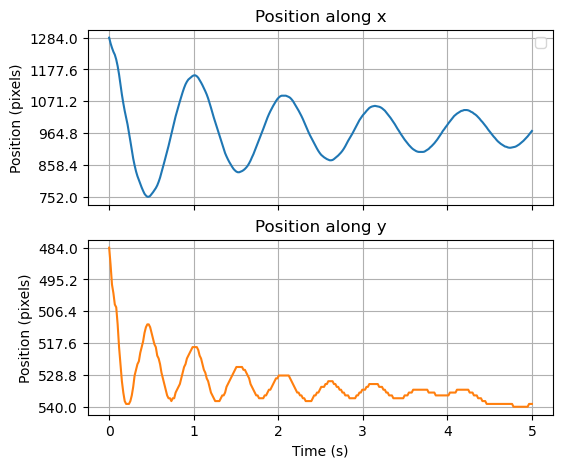

In [11]:
uw_m3 = uw_m3[(uw_m3['time'] > 0.65) & (uw_m3['time'] <= 5.65)]

plotter(uw_m3, 'Position along x', 'Position along y', 
        np.linspace(np.min(uw_m3['x']), np.max(uw_m3['x']), 6),
        np.linspace(np.min(uw_m3['y']), np.max(uw_m3['y']), 6), 
        np.linspace(np.min(uw_m3['time']), np.max(uw_m3['time']), 6),
        'plots', 'position vs time m3 in water')

## Theta Function in Air

In [12]:
theta_m1 = theta(m1, 1.15, 6.15)
theta_m2 = theta(m2, 0.45, 5.45)
theta_m3 = theta(m3, 0.0, 5)

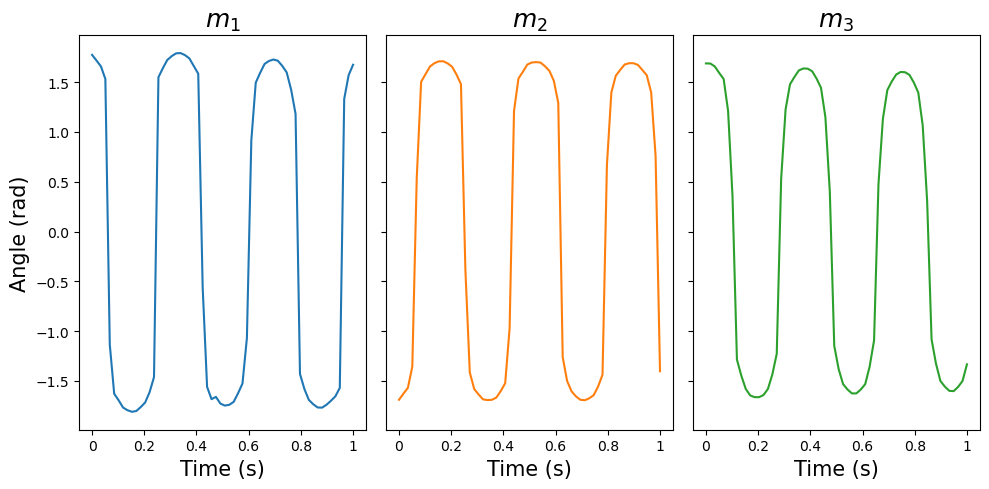

In [27]:
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(10, 5))

ax[0].plot(theta_m1['time'], theta_m1['angle'], color='C0')
ax[0].set_title('$m_1$', fontsize=18)
ax[0].set_ylabel('Angle (rad)', fontsize=15)
ax[0].set_xlabel('Time (s)', fontsize=15)
ax[0].set_xticks(np.linspace(np.min(theta_m1['time']), np.max(theta_m1['time']), 6))
ax[0].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1])

ax[1].plot(theta_m2['time'], theta_m2['angle'], color='C1')
ax[1].set_title('$m_2$', fontsize=18)
ax[1].set_xlabel('Time (s)', fontsize=15)
ax[1].set_xticks(np.linspace(np.min(theta_m2['time']), np.max(theta_m2['time']), 6))
ax[1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1])

ax[2].plot(theta_m3['time'], theta_m3['angle'], color='C2')
ax[2].set_title('$m_3$', fontsize=18)
ax[2].set_xlabel('Time (s)', fontsize=15)
ax[2].set_xticks(np.linspace(np.min(theta_m3['time']), np.max(theta_m3['time']), 6))
ax[2].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.tight_layout()
save_path = os.path.join('plots', "angle vs time of masses in air.png")
plt.savefig(save_path, dpi=300)

## Theta Function in Water

In [14]:
theta_uw_m1 = theta2(uw_m1, 2, 5)
theta_uw_m2 = theta2(uw_m2, 0.45, 5.45)
theta_uw_m3 = theta2(uw_m3, 0.65, 5.65)

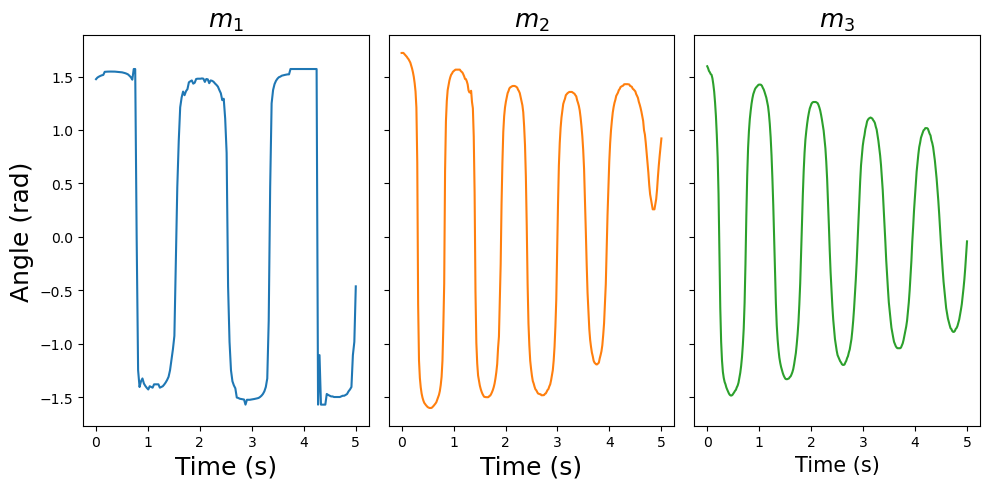

In [29]:
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(10, 5))

ax[0].plot(theta_uw_m1['time'], theta_uw_m1['angle'], color='C0')
ax[0].set_title('$m_1$', fontsize=18)
ax[0].set_ylabel('Angle (rad)', fontsize=18)
ax[0].set_xlabel('Time (s)', fontsize=18)
ax[0].set_xticks(np.linspace(np.min(theta_uw_m1['time']), np.max(theta_uw_m1['time']), 6))
ax[0].set_xticklabels([0, 1, 2, 3, 4, 5])


ax[1].plot(theta_uw_m2['time'], theta_uw_m2['angle'], color='C1')
ax[1].set_title('$m_2$', fontsize=18)
ax[1].set_xlabel('Time (s)', fontsize=18)
ax[1].set_xticks(np.linspace(np.min(theta_uw_m2['time']), np.max(theta_uw_m2['time']), 6))
ax[1].set_xticklabels([0, 1, 2, 3, 4, 5])

ax[2].plot(theta_uw_m3['time'], theta_uw_m3['angle'], color='C2')
ax[2].set_title('$m_3$', fontsize=18)
ax[2].set_xlabel('Time (s)', fontsize=15)
ax[2].set_xticks(np.linspace(np.min(theta_uw_m3['time']), np.max(theta_uw_m3['time']), 6))
ax[2].set_xticklabels([0, 1, 2, 3, 4, 5])

plt.tight_layout()
save_path = os.path.join('plots', "angle vs time of masses in water.png")
plt.savefig(save_path, dpi=300)

## Period and Buoyancy Calculations

In [16]:
## Reloading csvs to reset any transformations

uw_m1 = pd.read_csv(path + 'uw_m1_tracked_positions.csv')
uw_m2 = pd.read_csv(path + 'uw_m2_tracked_positions.csv')
uw_m3 = pd.read_csv(path + 'uw_m3_tracked_positions.csv')

m1 = pd.read_csv(path + 'M1T3_positions.csv')
m2 = pd.read_csv(path + 'M2T1_positions.csv')
m3 = pd.read_csv(path + 'M3T1_fixed_positions.csv')

spring_m3 = pd.read_csv(path + 'spring_m3_tracked_positions.csv')

uw_m1 = frame_to_sec(uw_m1, 60)
uw_m2 = frame_to_sec(uw_m2, 60)
uw_m3 = frame_to_sec(uw_m3, 60)

m1 = frame_to_sec(m1, 60)
m2 = frame_to_sec(m2, 60)
m3 = frame_to_sec(m3, 60)

spring_m3 = frame_to_sec(spring_m3, 60)

In [17]:
m1.head()

,frame,x,y,dx_from_ref,dy_from_ref,time
0,1,1351,416,382,-82,0.016667
1,2,1351,416,382,-82,0.033333
2,3,1350,416,381,-82,0.050000
3,4,1350,416,381,-82,0.066667
4,5,1351,415,382,-83,0.083333


In [18]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def period(df):
    df["r"] = np.sqrt(df["dx_from_ref"]**2 + df["dy_from_ref"]**2)
    
    signal_column = "r" 

    # === PREPARE SIGNAL ===
    df = df.dropna(subset=[signal_column])
    t = df['time']
    signal = df[signal_column].values

    # Optional: smooth to reduce noise
    window = 5
    signal_smooth = np.convolve(signal, np.ones(window)/window, mode="same")

    # === FIND PEAKS ===
    # Adjust `distance` if too many/too few peaks are found
    peaks, _ = find_peaks(signal_smooth, distance=60/4)
    peak_times = t.iloc[peaks].values

    if len(peak_times) > 1:
        periods = np.diff(peak_times)
        mean_period = np.mean(periods)
        std_period = np.std(periods)
        print(f"Estimated period: {mean_period:.3f} s ± {std_period:.3f} s "
              f"(based on {len(periods)} oscillations)")
    else:
        print("⚠️ Not enough peaks detected to estimate period.")

    # === VISUALIZE ===
    # plt.figure(figsize=(10,4))
    # plt.plot(t, signal_smooth, label=f"{signal_column} (smoothed)")
    # plt.plot(peak_times, signal_smooth[peaks], "rx", label="Detected peaks")
    # plt.xlabel("Time (s)")
    # plt.ylabel(f"{signal_column} (pixels)")
    # plt.title("Pendulum Oscillation")
    # plt.legend()
    # plt.show()

In [19]:
print('\n #################### period in air ####################  \n')

period(m1)
period(m2)
period(m3)

print('\n #################### period in water ####################  \n')

period(uw_m1)
period(uw_m2)
period(uw_m3)


 #################### period in air ####################  

Estimated period: 0.361 s ± 0.055 s (based on 57 oscillations)
Estimated period: 0.358 s ± 0.008 s (based on 35 oscillations)
Estimated period: 0.373 s ± 0.043 s (based on 37 oscillations)

 #################### period in water ####################  

Estimated period: 0.508 s ± 0.060 s (based on 11 oscillations)
Estimated period: 0.618 s ± 0.173 s (based on 17 oscillations)
Estimated period: 0.543 s ± 0.049 s (based on 14 oscillations)


In [20]:
l1 = 18.25 / 100 
l2 = 18.5 / 100
l3 = 18.75 / 100

mass1 = 20 / 1000 # grams
mass2 = 101 / 1000
mass3 = 200 / 1000

def per_w_buoy(L, m):

    rho_water = 1000
    rho_steel = 7850
    g = 9.81

    g_eff = (1 - (rho_water/rho_steel)) * g
    m_eff = (1 - 0.5*(rho_water/rho_steel)) * m
    
    return ( 4 * (np.pi**2) * (m_eff * L) ) / ( m * g_eff )

In [21]:
pwb_m1 = per_w_buoy(l1, mass1)
pwb_m2 = per_w_buoy(l2, mass2)
pwb_m3 = per_w_buoy(l3, mass3)

print(f'{pwb_m1:.3f}')
print(f'{pwb_m2:.3f}')
print(f'{pwb_m3:.3f}')

0.788
0.799
0.810
